In [7]:
# 套件區域
# ==========================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import warnings
import math
import os
import sqlite3
import logging
import time
import json

# 忽略 pandas 和 statsmodels 的警告以保持輸出整潔
warnings.filterwarnings('ignore')

In [8]:
# 參數區域
# ==========================================
FAST_TEST_MODE = True
if FAST_TEST_MODE:
    print("【快速測試模式】: 僅回測 2019-2022 年間之科技板塊。")
    # 縮短時間：涵蓋 2020 疫情崩盤與 2022 升息的壓力測試區間
    START_DATE = '2019-01-01'
    END_DATE = '2022-12-31'
    # 縮小股票池：僅測試單一板塊，運算量大幅減少
    TARGET_SECTOR = None  
else:
    print("【完整回測模式】: 回測 2000-2025 年間之全市場 S&P 500。")
    # 論文要求的全樣本時間
    START_DATE = '2000-01-01'
    END_DATE = '2025-12-31'
    # 測試全市場 (設為 None 代表不限制單一產業)
    TARGET_SECTOR = None  

# 資料庫配置
DB_PATH = r'..\data\sp500.db'
IMPUTED_SECTOR_PATH = r'..\data\imputed_sectors.csv'
USE_DYNAMIC_SECTORS = True  # 是否使用動態產業補齊

# 視窗參數
FORMATION_WINDOW = 252    # 約 1 年
TRADING_WINDOW = 126      # 約 6 個月
ROLLING_WINDOW = 21       # 約 1 個月 (梯隊步長)
MIN_HISTORY_DAYS = 200    # 最少歷史資料

# 配對篩選參數
TOP_N_PAIRS = 10          # 每個視窗選出前 N 組配對
P_THRESHOLD = 0.01

# 交易參數
Z_ENTRY = 2.0               # 進場標準差閾值（SSD 方法中改用 2×σ_formation）
Z_EXIT = 0.0                # 平倉標準差閾值
TRANSACTION_COST = 0.0029   # 單邊交易成本 (0.29%)
MAX_LOSS_PCT = 0.03         # 停損 (0 = 無停損)

# 資金配置
INITIAL_CAPITAL = 10000  # 初始本金
CAPITAL_TRANCHES = math.ceil(TRADING_WINDOW / ROLLING_WINDOW)

# 確保路徑存在
os.makedirs(os.path.dirname(IMPUTED_SECTOR_PATH), exist_ok=True)

print(f"""
【回測參數設置】
時間期間: {START_DATE} ~ {END_DATE}
形成期: {FORMATION_WINDOW} 天
交易期: {TRADING_WINDOW} 天
步長: {ROLLING_WINDOW} 天
配對數: {TOP_N_PAIRS}
初始資金: ${INITIAL_CAPITAL:,.0f}
交易成本: {TRANSACTION_COST*100:.2f}%
""")

【快速測試模式】: 僅回測 2019-2022 年間之科技板塊。

【回測參數設置】
時間期間: 2019-01-01 ~ 2022-12-31
形成期: 252 天
交易期: 126 天
步長: 21 天
配對數: 10
初始資金: $10,000
交易成本: 0.29%



In [9]:
# ==========================================
class FetchData:
    def __init__(self, db_path, start_date, end_date, target_sector, use_dynamic, min_days, imputed_path=IMPUTED_SECTOR_PATH):
        self.db_path = db_path
        self.start_date = start_date
        self.end_date = end_date
        self.target_sector = target_sector
        self.use_dynamic = use_dynamic
        self.imputed_path = imputed_path
        self.min_days = min_days
        
        # 確保快取路徑存在
        os.makedirs(os.path.dirname(self.imputed_path), exist_ok=True)

    def fix_unknown_sectors(self, sector_df):
        """具備本機快取與全域開關控制的產業補齊"""
        if not self.use_dynamic:
            print("不使用動態產業補齊。")
            return sector_df

        if os.path.exists(self.imputed_path):
            print(f"從本機快取載入已補齊的產業分類: {self.imputed_path}")
            cached_df = pd.read_csv(self.imputed_path)
            update_df = cached_df.set_index('ticker')
            sector_df = sector_df.set_index('ticker')
            sector_df.update(update_df)
            return sector_df.reset_index()

        unknown_mask = sector_df['sector'] == 'Unknown'
        unknown_tickers = sector_df[unknown_mask]['ticker'].tolist()
        
        if not unknown_tickers:
            return sector_df

        print(f"找不到本機快取，正在透過 API 補齊 {len(unknown_tickers)} 檔股票的產業分類...")
        yf_logger = logging.getLogger('yfinance')
        original_level = yf_logger.level
        yf_logger.setLevel(logging.CRITICAL) 
        
        fixed_sectors = []
        for i, ticker in enumerate(unknown_tickers):
            try:
                info = yf.Ticker(ticker).info
                sector = info.get('sector', 'Unknown')
                fixed_sectors.append({'ticker': ticker, 'sector': sector})
                time.sleep(0.02) 
            except Exception:
                fixed_sectors.append({'ticker': ticker, 'sector': 'Unknown'})
                
            if (i + 1) % 50 == 0:
                print(f"已處理 {i + 1} / {len(unknown_tickers)}...")
                
        yf_logger.setLevel(original_level)
        
        fetched_df = pd.DataFrame(fixed_sectors)
        fetched_df.to_csv(self.imputed_path, index=False)
        print(f"API 抓取完畢！已將動態產業分類永久儲存至: {self.imputed_path}")
        
        update_df = fetched_df.set_index('ticker')
        sector_df = sector_df.set_index('ticker')
        sector_df.update(update_df)
        sector_df = sector_df.reset_index()
        
        remaining = len(sector_df[sector_df['sector'] == 'Unknown'])
        print(f"補齊完成！剩餘真實無法識別(已下市)的股票數量: {remaining}")
        return sector_df

    def preprocess_prices(self, prices_df, sector_df):
        """數據預處理：樞紐、前向填充、去除稀疏股票與 Unknown 產業"""
        pivot = prices_df.pivot_table(index='date', columns='ticker', values='close', aggfunc='last')
        pivot.index = pd.to_datetime(pivot.index)
        pivot.sort_index(inplace=True)
        
        # 前向填充（最多 5 天）
        pivot.ffill(limit=5, inplace=True)
        
        # 保留有足夠歷史資料的股票
        valid = pivot.columns[pivot.notna().sum() >= self.min_days]
        pivot = pivot[valid]
        
        # 篩選掉 Sector 為 'Unknown' 的股票
        known_tickers = sector_df[sector_df['sector'] != 'Unknown']['ticker'].tolist()
        final_valid = [col for col in pivot.columns if col in known_tickers]
        pivot = pivot[final_valid]
        
        print(f'✓ 數據矩陣：{len(pivot)} 天 × {len(pivot.columns)} 檔股票')
        print(f'✓ 時間範圍：{pivot.index[0].date()} ~ {pivot.index[-1].date()}')
        
        return pivot

    def fetch_all(self):
        """整合：讀取產業、補齊產業、生成 SQL 條件篩選價量、數據預處理"""
        if not os.path.exists(self.db_path):
            self._create_dummy_db()

        conn = sqlite3.connect(self.db_path)
        
        # 1. 優先加載行業分類
        print("\n從資料庫加載行業數據...")
        sector_queries = [
            "SELECT ticker, sector FROM tickers",
            "SELECT ticker, sector FROM sp500_components GROUP BY ticker",
        ]
        
        sector_df = None
        for q in sector_queries:
            try:
                sector_df = pd.read_sql_query(q, conn)
                if len(sector_df) > 0:
                    print(f'✓ 加載行業數據：{len(sector_df):,} 檔股票')
                    break
            except Exception:
                continue
                
        if sector_df is None or len(sector_df) == 0:
            print('⚠️ 未找到行業表，建立空的 DataFrame。')
            sector_df = pd.DataFrame(columns=['ticker', 'sector'])
            
        # 2. 動態補齊產業
        sector_df = self.fix_unknown_sectors(sector_df)
        
        # 3. 處理 Target Sector 並組裝 SQL IN 條件
        ticker_filter_sql = ""
        if self.target_sector is not None:
            target_tickers = sector_df[sector_df['sector'] == self.target_sector]['ticker'].tolist()
            print(f"🎯 板塊過濾：將在 SQL 階段嚴格篩選 {self.target_sector} 板塊之股票，共 {len(target_tickers)} 檔")
            
            if not target_tickers:
                conn.close()
                raise ValueError(f"資料庫中找不到屬於 {self.target_sector} 的股票！")
            
            # 建立 SQL 所需的 IN 字串格式
            if len(target_tickers) == 1:
                ticker_filter_sql = f" AND ticker = '{target_tickers[0]}'"
            else:
                ticker_filter_sql = f" AND ticker IN {tuple(target_tickers)}"
            
            # 過濾 DataFrame 以便後續匹配
            sector_df = sector_df[sector_df['sector'] == self.target_sector]
        else:
            print("🌍 全市場模式：將加載所有符合時間條件的股票")

        # 4. 在 SQL 階段即加上 ticker_filter_sql 篩選，降低記憶體浪費
        print("\n從資料庫加載價格數據...")
        price_queries = [
            (f"SELECT date, ticker, adj_close AS close FROM daily_prices "
             f"WHERE date BETWEEN '{self.start_date}' AND '{self.end_date}'{ticker_filter_sql} ORDER BY date"),
            (f"SELECT date, ticker, close FROM stock_prices "
             f"WHERE date BETWEEN '{self.start_date}' AND '{self.end_date}'{ticker_filter_sql} ORDER BY date"),
        ]
        
        prices_df = None
        for q in price_queries:
            try:
                prices_df = pd.read_sql_query(q, conn, parse_dates=['date'])
                if len(prices_df) > 0:
                    print(f'✓ 加載價格數據：{len(prices_df):,} 筆記錄')
                    break
            except Exception:
                continue
        
        conn.close()
        
        if prices_df is None or len(prices_df) == 0:
            raise RuntimeError("無法從資料庫加載價格數據，請確認資料表名稱與欄位。")

        # 5. 數據預處理 (樞紐、前向填充、剃除 Unknown)
        print("\n預處理價格數據...")
        price_pivot = self.preprocess_prices(prices_df, sector_df)
        
        # 6. 徹底清理 Unknown 並建立行業對應字典
        valid_tickers = price_pivot.columns.tolist()
        # 確保完全排除 Unknown，且只加入有價格數據的有效 ticker
        sector_df_valid = sector_df[sector_df['sector'] != 'Unknown']
        sector_map = sector_df_valid[sector_df_valid['ticker'].isin(valid_tickers)].set_index('ticker')['sector'].to_dict()
        
        return price_pivot, sector_map

In [10]:
class CointPairsTrading:
    def __init__(self, data, sector_map, formation_days, trading_days, rolling_window, capital_tranches, initial_capital, z_entry, z_exit, top_n_pairs, p_threshold, fee, max_loss_pct):
        self.data = data
        self.sector_map = sector_map
        self.formation_days = formation_days
        self.trading_days = trading_days
        self.rolling_window = rolling_window
        self.capital_tranches = capital_tranches
        self.initial_capital = initial_capital
        self.top_n_pairs = top_n_pairs
        self.p_threshold = p_threshold
        self.entry = z_entry
        self.exit = z_exit
        self.fee = fee
        self.max_loss_pct = max_loss_pct
        
        self.portfolio_returns = []
        self.cumulative_returns = []
        self.history_pairs = []  # 紀錄歷年來選出的所有配對，供匯出調用

    def find_best_pairs(self, formation_data):
        log_data = np.log(formation_data)
        coint_results = []

        sector_tickers = {}
        for ticker, sector in self.sector_map.items():
            if ticker in log_data.columns:
                sector_tickers.setdefault(sector, []).append(ticker)

        # 仍在同產業內尋找配對 (避免不相關產業的假性共整合，且大幅節省運算時間)
        for sector, tickers in sector_tickers.items():
            if len(tickers) < 2: continue
            
            for stock_a, stock_b in combinations(tickers, 2):
                try:
                    y = log_data[stock_a].dropna()
                    x = log_data[stock_b].dropna()
                    
                    common_idx = y.index.intersection(x.index)
                    if len(common_idx) < self.formation_days * 0.8: continue
                    
                    y, x = y.loc[common_idx], x.loc[common_idx]
                    x_with_const = sm.add_constant(x)
                    
                    ols_model = sm.OLS(y, x_with_const).fit()
                    alpha = ols_model.params.get('const', 0)
                    beta = ols_model.params.iloc[1] if 'const' in ols_model.params else ols_model.params.iloc[0]
                    residuals = ols_model.resid
                    
                    adf_result = adfuller(residuals, maxlag=1)
                    p_value = adf_result[1]
                    
                    if p_value < self.p_threshold:
                        std_spread = residuals.std()
                        coint_results.append({
                            'Pair': (stock_a, stock_b),
                            'Sector': sector,
                            'p_value': p_value,
                            'alpha': alpha,
                            'beta': beta,
                            'Std': std_spread
                        })
                except Exception:
                    continue

        if not coint_results:
            return pd.DataFrame()

        coint_df = pd.DataFrame(coint_results)
        
        # 全市場不分產業，直接挑出 p-value 最小的前 N 對
        best_pairs = coint_df.nsmallest(self.top_n_pairs, 'p_value').reset_index(drop=True)
        
        return best_pairs

    def trade_pairs(self, trading_data, selected_pairs, window_capital):
        period_pnl = np.zeros(len(trading_data))
        if selected_pairs.empty:
            return period_pnl

        log_data = np.log(trading_data)
        num_pairs = len(selected_pairs)
        capital_per_pair = int(window_capital // num_pairs)
        
        pair_params = []
        for _, row in selected_pairs.iterrows():
            stock_a = row['Pair'][0]
            stock_b = row['Pair'][1]
            beta = row['beta']
            total_weight = 1 + abs(beta)
            w_a = 1 / total_weight
            w_b = abs(beta) / total_weight
            sign_beta = np.sign(beta)
            
            spread = log_data[stock_a] - beta * log_data[stock_b] - row['alpha']
            ret_a = trading_data[stock_a].pct_change().fillna(0).values
            ret_b = trading_data[stock_b].pct_change().fillna(0).values
            
            pair_params.append({
                'stock_a': stock_a,
                'stock_b': stock_b,
                'spread': spread.values,
                'ret_a': ret_a,
                'ret_b': ret_b,
                'w_a': w_a,
                'w_b': w_b,
                'sign_beta': sign_beta,
                'entry_threshold': self.entry * row['Std'],
                'exit_threshold': self.exit,
                'pos': 0,
                'cumulative_pnl': 0.0  # 紀錄單一配對在整個視窗的淨損益
            })
            
        stopped_out = False
        cumulative_pnl = 0.0
        
        for t in range(1, len(trading_data)):
            if stopped_out:
                break 
                
            daily_mtm = 0.0
            daily_cost = 0.0
            
            for p in pair_params:
                pos = p['pos']
                pair_mtm = 0.0
                
                # 計算該配對今日 MTM PnL
                if pos == 1: 
                    pair_mtm = capital_per_pair * (p['w_a'] * p['ret_a'][t] - p['sign_beta'] * p['w_b'] * p['ret_b'][t])
                elif pos == -1: 
                    pair_mtm = capital_per_pair * (-p['w_a'] * p['ret_a'][t] + p['sign_beta'] * p['w_b'] * p['ret_b'][t])
                    
                daily_mtm += pair_mtm
                
                current_spread = p['spread'][t]
                new_pos = pos
                
                if pos == 1 and current_spread >= p['exit_threshold']:
                    new_pos = 0
                elif pos == -1 and current_spread <= p['exit_threshold']:
                    new_pos = 0
                    
                if new_pos == 0:
                    if current_spread > p['entry_threshold']:
                        new_pos = -1
                    elif current_spread < -p['entry_threshold']:
                        new_pos = 1
                        
                # 計算該配對今日交易成本
                pair_cost = 0.0
                if new_pos != pos:
                    trades = abs(new_pos - pos)
                    pair_cost = trades * capital_per_pair * self.fee
                    daily_cost += pair_cost
                    
                p['pos'] = new_pos
                p['cumulative_pnl'] += (pair_mtm - pair_cost)  # 累積該配對專屬損益
                
            today_pnl = daily_mtm - daily_cost
            period_pnl[t] = today_pnl
            cumulative_pnl += today_pnl
            
            # 判斷整體視窗停損
            if self.max_loss_pct > 0 and cumulative_pnl < -self.max_loss_pct * window_capital:
                stopped_out = True
                force_close_cost = 0.0
                for p in pair_params:
                    if p['pos'] != 0:
                        close_cost = abs(0 - p['pos']) * capital_per_pair * self.fee
                        force_close_cost += close_cost
                        p['cumulative_pnl'] -= close_cost
                        p['pos'] = 0
                
                period_pnl[t] -= force_close_cost
                cumulative_pnl -= force_close_cost
                
        # 視窗結束，印出單一配對的細部結算
        print("\n  --- 視窗內各配對損益結算 ---")
        for p in pair_params:
            pair_name = f"{p['stock_a']}-{p['stock_b']}"
            roi = (p['cumulative_pnl'] / capital_per_pair) * 100 if capital_per_pair > 0 else 0
            print(f"  配對 {pair_name:<11} | 分配資金: ${capital_per_pair:,.0f} | 淨損益: ${p['cumulative_pnl']:>8.2f} | 區間報酬: {roi:>6.2f}%")
                
        return period_pnl

    def run_backtest(self):
        total_days = len(self.data)
        print(f"\n開始執行共整合配對回測... (總交易日: {total_days} 天)")
        
        window_capital = int(self.initial_capital // self.capital_tranches)
        print(f"分配機制: 總資金 ${self.initial_capital:,.0f} 切分為 {self.capital_tranches} 個視窗，每個視窗總分配本金 ${window_capital:,.0f}")
        
        portfolio_pnl = np.zeros(total_days)
        
        for start_idx in range(0, total_days - self.formation_days - self.trading_days + 1, self.rolling_window):
            form_end_idx = start_idx + self.formation_days
            trade_end_idx = form_end_idx + self.trading_days
            
            formation_data = self.data.iloc[start_idx:form_end_idx]
            trading_data = self.data.iloc[form_end_idx:trade_end_idx]
            
            best_pairs = self.find_best_pairs(formation_data)
            
            print(f"\n" + "="*50)
            print(f"新視窗期間: {trading_data.index[0].date()} 至 {trading_data.index[-1].date()}")
            if best_pairs.empty:
                print("  本期無顯著共整合配對 (未達 P-value 門檻)。")
            else:
                for _, row in best_pairs.iterrows():
                    print(f"  選定配對: {row['Pair'][0]:<5} & {row['Pair'][1]:<5} | Sector: {row['Sector']:<25} | p-value: {row['p_value']:.4f} | Beta: {row['beta']:.2f}")
                
                # 紀錄歷史選出的配對 (供未來匯出數據調用)
                record_df = best_pairs.copy()
                record_df['Window_Start'] = trading_data.index[0].date()
                record_df['Window_End'] = trading_data.index[-1].date()
                self.history_pairs.append(record_df)
                
            # 計算該視窗各配對與整體獲利
            cohort_pnl = self.trade_pairs(trading_data, best_pairs, window_capital)
            portfolio_pnl[form_end_idx:trade_end_idx] += cohort_pnl
            
            # 印出整個視窗的總報酬與資金變化
            window_total_pnl = cohort_pnl.sum()
            window_roi = (window_total_pnl / window_capital) * 100 if window_capital > 0 else 0
            print(f"  >>> 【視窗結算】 視窗投入本金: ${window_capital:,.0f} | 視窗總淨利: ${window_total_pnl:,.2f} | 總報酬: {window_roi:.2f}%")
            print("="*50)
            
        dates = self.data.index
        self.cumulative_returns = pd.Series(self.initial_capital + np.cumsum(portfolio_pnl), index=dates)
        self.portfolio_returns = self.cumulative_returns.pct_change().fillna(0)
        
        self._print_statistics()
        self._plot_results()

    def _print_statistics(self):
        annualized_return = self.portfolio_returns.mean() * 252
        annualized_vol = self.portfolio_returns.std() * np.sqrt(252)
        sharpe_ratio = annualized_return / annualized_vol if annualized_vol != 0 else 0
        
        running_max = self.cumulative_returns.cummax()
        drawdown = (self.cumulative_returns - running_max) / running_max
        max_drawdown = drawdown.min()
        final_value = self.cumulative_returns.iloc[-1] if not self.cumulative_returns.empty else self.initial_capital
        
        print("\n" + "="*40)
        print("【共整合配對回測績效統計】")
        print(f"年化報酬率: {annualized_return*100:.2f}%")
        print(f"年化波動率: {annualized_vol*100:.2f}%")
        print(f"夏普值 (Sharpe Ratio): {sharpe_ratio:.2f}")
        print(f"最大回撤 (Max Drawdown): {max_drawdown*100:.2f}%")
        print(f"期末淨值: ${final_value:,.2f} (初始本金 ${self.initial_capital:,.2f})")
        print("="*40)

    def _plot_results(self):
        # 計算最大回撤序列
        running_max = self.cumulative_returns.cummax()
        drawdown = (self.cumulative_returns - running_max) / running_max

        # 計算 126 天期 (約半年) 滾動年化夏普值
        rolling_return = self.portfolio_returns.rolling(window=126).mean() * 252
        rolling_vol = self.portfolio_returns.rolling(window=126).std() * np.sqrt(252)
        rolling_sharpe = rolling_return / rolling_vol.replace(0, np.nan) # 避免除以零
        rolling_sharpe = rolling_sharpe.fillna(0)

        # 建立 3 張子圖 (Grid)
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1, 1.2]})

        # 子圖 1：累計投資組合價值
        ax1.plot(self.cumulative_returns.index, self.cumulative_returns.values, label='Portfolio Value (USD)', color='navy')
        ax1.set_title('Cumulative Portfolio Value of Cointegration Pairs Trading', fontsize=14)
        ax1.set_ylabel('Portfolio Value (USD)')
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax1.legend(loc='upper left')

        # 子圖 2：最大回撤 (Max Drawdown)
        ax2.fill_between(drawdown.index, drawdown.values * 100, 0, color='crimson', alpha=0.5, label='Drawdown (%)')
        ax2.set_title('Maximum Drawdown (%)', fontsize=12)
        ax2.set_ylabel('Drawdown (%)')
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax2.legend(loc='lower left')

        # 子圖 3：滾動年化夏普值 (Rolling Sharpe Ratio)
        ax3.plot(rolling_sharpe.index, rolling_sharpe.values, color='forestgreen', label='126-Day Rolling Annualized Sharpe')
        ax3.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5) # 加入 0 軸輔助線
        ax3.set_title('Rolling Annualized Sharpe Ratio (126-Day Window)', fontsize=12)
        ax3.set_xlabel('Date')
        ax3.set_ylabel('Sharpe Ratio')
        ax3.grid(True, linestyle='--', alpha=0.6)
        ax3.legend(loc='upper left')

        plt.tight_layout()
        plt.show()

    def export_data(self, save_dir=r'..\results'):
        """將回測的數據結果與清洗好的原始數據匯出，供未來直接調用"""
        os.makedirs(save_dir, exist_ok=True)

        # 1. 匯出淨值與報酬率序列
        results_df = pd.DataFrame({
            'Daily_Return': self.portfolio_returns,
            'Cumulative_Value': self.cumulative_returns
        })
        nav_path = os.path.join(save_dir, 'coint_portfolio_nav.csv')
        results_df.to_csv(nav_path)

        # 2. 匯出交易配對紀錄
        if self.history_pairs:
            pairs_df = pd.concat(self.history_pairs, ignore_index=True)
            # 將 Pair Tuple 拆分成 Stock_A 與 Stock_B 方便閱讀與調用
            pairs_df['Stock_A'] = pairs_df['Pair'].apply(lambda x: x[0])
            pairs_df['Stock_B'] = pairs_df['Pair'].apply(lambda x: x[1])
            # 重新排序欄位
            pairs_df = pairs_df[['Window_Start', 'Window_End', 'Sector', 'Stock_A', 'Stock_B', 'p_value', 'alpha', 'beta', 'Std']]
            pairs_path = os.path.join(save_dir, 'coint_traded_pairs.csv')
            pairs_df.to_csv(pairs_path, index=False)
        else:
            pairs_path = "無配對紀錄"

        # 3. 匯出預處理後的清洗價格矩陣 (Pickle 讀取速度極快，能保存 Index 結構)
        price_path = os.path.join(save_dir, 'coint_price_pivot.pkl')
        self.data.to_pickle(price_path)

        # 4. 匯出無 Unknown 的產業對應字典 (JSON 格式)
        sector_path = os.path.join(save_dir, 'coint_sector_map.json')
        with open(sector_path, 'w', encoding='utf-8') as f:
            json.dump(self.sector_map, f, ensure_ascii=False, indent=4)

        print("\n" + "="*40)
        print(f"【數據匯出完成】 所有回測數據已儲存至: {save_dir}")
        print(f" 1. 投資組合淨值: {nav_path}")
        print(f" 2. 歷史交易配對: {pairs_path}")
        print(f" 3. 清洗後價格矩陣: {price_path} (請用 pd.read_pickle 調用)")
        print(f" 4. 產業對應字典: {sector_path} (請用 json.load 調用)")
        print("="*40)


從資料庫加載行業數據...
✓ 加載行業數據：843 檔股票
從本機快取載入已補齊的產業分類: ..\data\imputed_sectors.csv
🌍 全市場模式：將加載所有符合時間條件的股票

從資料庫加載價格數據...
✓ 加載價格數據：616,467 筆記錄

預處理價格數據...
✓ 數據矩陣：1008 天 × 614 檔股票
✓ 時間範圍：2019-01-02 ~ 2022-12-30

【行業分佈】
Industrials               90
Financials                76
Information Technology    69
Health Care               58
Consumer Discretionary    48
Real Estate               36
Consumer Cyclical         36
Consumer Staples          35
Energy                    34
Utilities                 32
Name: count, dtype: int64


開始執行共整合配對回測... (總交易日: 1008 天)
分配機制: 總資金 $10,000 切分為 6 個視窗，每個視窗總分配本金 $1,666

新視窗期間: 2020-01-02 至 2020-07-01
  選定配對: CBOE  & FIS   | Sector: Financials                | p-value: 0.0000 | Beta: 0.90
  選定配對: PPG   & SW    | Sector: Materials                 | p-value: 0.0000 | Beta: 0.70
  選定配對: NVR   & POOL  | Sector: Consumer Discretionary    | p-value: 0.0000 | Beta: 1.18
  選定配對: INCY  & UNH   | Sector: Health Care               | p-value: 0.0000 | Beta: 0.62
  選定配對: 

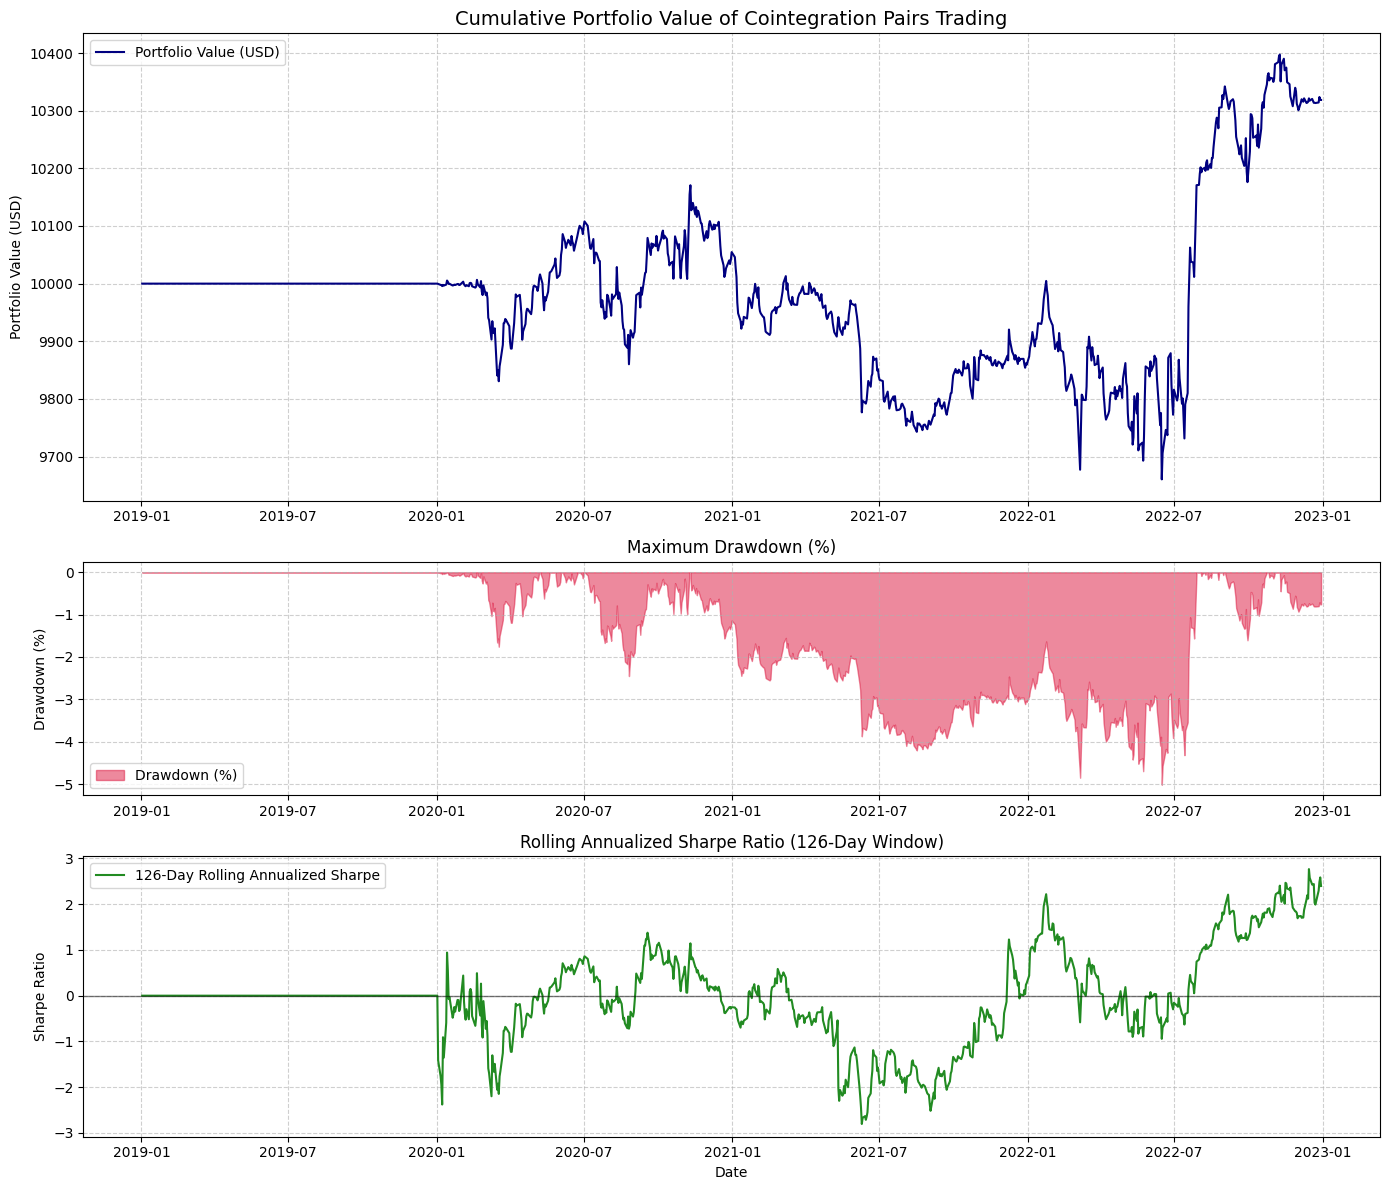


【數據匯出完成】 所有回測數據已儲存至: ..\results
 1. 投資組合淨值: ..\results\coint_portfolio_nav.csv
 2. 歷史交易配對: ..\results\coint_traded_pairs.csv
 3. 清洗後價格矩陣: ..\results\coint_price_pivot.pkl (請用 pd.read_pickle 調用)
 4. 產業對應字典: ..\results\coint_sector_map.json (請用 json.load 調用)


In [11]:
# 執行區域
# ==========================================
if __name__ == "__main__":
    # 使用 FetchData 類別進行統一調用
    data_fetcher = FetchData(
        db_path=DB_PATH,
        start_date=START_DATE,
        end_date=END_DATE,
        target_sector=TARGET_SECTOR,
        use_dynamic=USE_DYNAMIC_SECTORS,
        imputed_path=IMPUTED_SECTOR_PATH,
        min_days=MIN_HISTORY_DAYS
    )
    
    price_pivot, sector_map = data_fetcher.fetch_all()
    
    print(f'\n【行業分佈】\n{pd.Series(sector_map).value_counts().head(10)}\n')

    # 執行回測
    backtester = CointPairsTrading(
        data=price_pivot, 
        sector_map=sector_map,
        formation_days=FORMATION_WINDOW,
        trading_days=TRADING_WINDOW,
        rolling_window=ROLLING_WINDOW,
        capital_tranches=CAPITAL_TRANCHES,
        initial_capital=INITIAL_CAPITAL,
        z_entry=Z_ENTRY,
        z_exit=Z_EXIT,
        top_n_pairs=TOP_N_PAIRS,
        p_threshold=P_THRESHOLD,
        fee=TRANSACTION_COST,
        max_loss_pct=MAX_LOSS_PCT
    )

    backtester.run_backtest()
    
     # 執行數據匯出
    backtester.export_data()